# 1. Data Preparation

In [1]:
import torchvision 
import torchvision.transforms as transforms

full_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
) 

/home/gantumur/miniconda3/envs/env/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [50]:
type(full_dataset).__mro__

(torchvision.datasets.cifar.CIFAR10,
 torchvision.datasets.vision.VisionDataset,
 torch.utils.data.dataset.Dataset,
 typing.Generic,
 object)

In [52]:
img, label = full_dataset[99]
img, label

(<PIL.Image.Image image mode=RGB size=32x32>, 1)

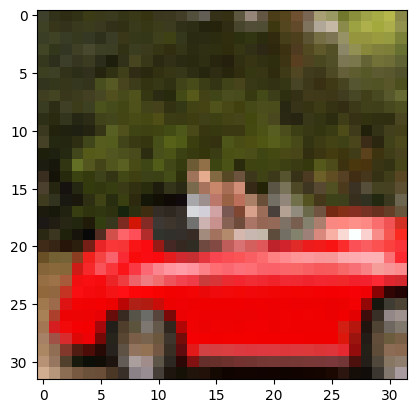

In [53]:
import matplotlib.pyplot as plt 

plt.imshow(img)
plt.show()

In [54]:
import torchvision.transforms

dir(transforms)

['AugMix',
 'AutoAugment',
 'AutoAugmentPolicy',
 'CenterCrop',
 'ColorJitter',
 'Compose',
 'ConvertImageDtype',
 'ElasticTransform',
 'FiveCrop',
 'GaussianBlur',
 'Grayscale',
 'InterpolationMode',
 'Lambda',
 'LinearTransformation',
 'Normalize',
 'PILToTensor',
 'Pad',
 'RandAugment',
 'RandomAdjustSharpness',
 'RandomAffine',
 'RandomApply',
 'RandomAutocontrast',
 'RandomChoice',
 'RandomCrop',
 'RandomEqualize',
 'RandomErasing',
 'RandomGrayscale',
 'RandomHorizontalFlip',
 'RandomInvert',
 'RandomOrder',
 'RandomPerspective',
 'RandomPosterize',
 'RandomResizedCrop',
 'RandomRotation',
 'RandomSolarize',
 'RandomVerticalFlip',
 'Resize',
 'TenCrop',
 'ToPILImage',
 'ToTensor',
 'TrivialAugmentWide',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '_functional_pil',
 '_functional_tensor',
 '_presets',
 'autoaugment',
 'functional',
 'transforms']

In [55]:
to_tensor = transforms.ToTensor()
img_t = to_tensor(img)
img_t

tensor([[[0.2431, 0.1961, 0.1804,  ..., 0.6549, 0.7176, 0.5373],
         [0.2471, 0.2157, 0.2039,  ..., 0.6392, 0.6706, 0.5686],
         [0.2275, 0.2510, 0.2196,  ..., 0.6000, 0.5882, 0.4824],
         ...,
         [0.6745, 0.5608, 0.5098,  ..., 0.3686, 0.5529, 0.5451],
         [0.7176, 0.5882, 0.3137,  ..., 0.3176, 0.5294, 0.5608],
         [0.8196, 0.7137, 0.5451,  ..., 0.2314, 0.5098, 0.6627]],

        [[0.2510, 0.1961, 0.1725,  ..., 0.6745, 0.7216, 0.5333],
         [0.2549, 0.2078, 0.1961,  ..., 0.6627, 0.6824, 0.5725],
         [0.2431, 0.2588, 0.2353,  ..., 0.6078, 0.6039, 0.5020],
         ...,
         [0.5294, 0.4314, 0.2196,  ..., 0.2941, 0.4235, 0.4118],
         [0.5725, 0.4627, 0.2510,  ..., 0.2824, 0.4627, 0.4902],
         [0.6824, 0.5922, 0.4275,  ..., 0.2118, 0.4667, 0.6118]],

        [[0.1725, 0.1020, 0.0745,  ..., 0.2706, 0.2980, 0.2824],
         [0.1451, 0.1020, 0.1059,  ..., 0.2392, 0.2941, 0.3020],
         [0.1412, 0.1451, 0.1451,  ..., 0.2431, 0.2510, 0.

## 1.1 Transform

In [79]:
import torchvision.transforms as transforms

dataset = torchvision.datasets.CIFAR10(root="./data", train=True, download=False, transform=transforms.ToTensor())




/home/gantumur/miniconda3/envs/env/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [80]:
img_t, _ = dataset[99]
type(img_t)

torch.Tensor

In [81]:
img_t.shape, img_t.dtype

(torch.Size([3, 32, 32]), torch.float32)

In [82]:
img_t.min(), img_t.max()

(tensor(0.), tensor(1.))

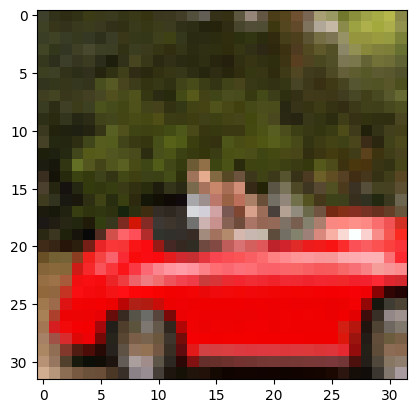

In [83]:
plt.imshow(img_t.permute(1, 2, 0))
plt.show()

## 1.2 Normalization

In [84]:
import torch 

imgs = torch.stack([img_t for img_t, _ in dataset], dim=3)
imgs.shape

torch.Size([3, 32, 32, 50000])

In [85]:
mean = imgs.view(3, -1).mean(dim=1)
mean

tensor([0.4914, 0.4822, 0.4465])

In [86]:
std = imgs.view(3, -1).std(dim=1)
std

tensor([0.2470, 0.2435, 0.2616])

In [87]:
transforms.Normalize(mean, std)

Normalize(mean=tensor([0.4914, 0.4822, 0.4465]), std=tensor([0.2470, 0.2435, 0.2616]))

In [5]:
# Useable 
import torchvision 
import torchvision.transforms as transforms 

mean = [0.4914, 0.4822, 0.4465]
std = [0.2470, 0.2435, 0.2616]

transformed_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=False,
    transform =transforms.Compose([transforms.ToTensor(), transforms.Normalize(mean, std)])
)

/home/gantumur/miniconda3/envs/env/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [6]:
transformed_val = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=False,
    transform=transforms.Compose([transforms.ToTensor(), transforms.Normalize(mean, std)])
)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9802876..2.1264887].


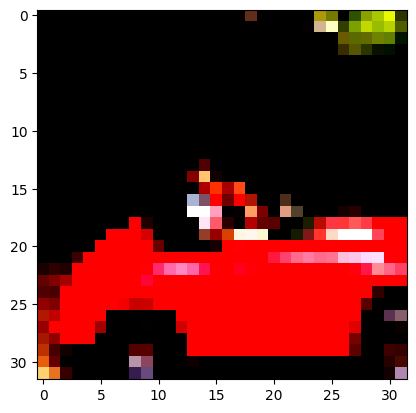

In [8]:
import matplotlib.pyplot as plt 

img_t, _ = transformed_dataset[99]

plt.imshow(img_t.permute(1, 2, 0))
plt.show()

## 1.3 Data splitting

In [10]:
import torch 

train_size = int(len(transformed_dataset) * 0.8)
test_size = int(len(transformed_dataset) * 0.2)

train_set, test_set = torch.utils.data.random_split(transformed_dataset, [train_size, test_size])

print(train_set.__len__(), test_set.__len__())

40000 10000


In [11]:
trainloader = torch.utils.data.DataLoader(
    train_set,
    batch_size=16,
    shuffle=True,
)

testloader = torch.utils.data.DataLoader(
    test_set,
    batch_size=16,
    shuffle=False
)

valloader = torch.utils.data.DataLoader(
    transformed_val,
    batch_size=16,
    shuffle=False
)


# 2. Model 

In [1]:
import torch 
import torch.nn as nn 
import torch.nn.functional as F

class Resnet9(nn.Module):
    def __init__(self, num_classes=10):
        super(Resnet9, self).__init__()
        
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(64)

        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(128)
        self.conv3 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.shortcut1 = nn.Conv2d(64, 128, kernel_size=1)

        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        self.conv5 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.bn5 = nn.BatchNorm2d(256)
        self.shortcut2 = nn.Conv2d(128, 256, kernel_size=1)

        self.pool = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Linear(256, num_classes)

    
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))

        residual = self.shortcut1(out)
        out = F.relu(self.bn2(self.conv2(out)))
        out = self.bn3(self.conv3(out))
        out += residual 
        out = F.relu(out)

        residual = self.shortcut2(out)
        out = F.relu(self.bn4(self.conv4(out)))
        out = self.bn5(self.conv5(out))
        out += residual 
        out = F.relu(out)

        out = self.pool(out)
        out = torch.flatten(out, 1)
        out = self.fc(out)
        return out 



In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class Resnet14(nn.Module):
    def __init__(self, num_classes=10):
        super(Resnet14, self).__init__()

        # --- Input Layer ---
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(64)

        # --- Stage 1 (64 channels, 32x32) ---
        # Block 1
        self.conv2 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        # (Identity shortcut for Block 1 does not need a layer)

        # Block 2
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(64)
        self.conv5 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn5 = nn.BatchNorm2d(64)

        # --- Stage 2 (128 channels, 16x16) ---
        # Block 3 (Downsampling)
        self.conv6 = nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1)
        self.bn6 = nn.BatchNorm2d(128)
        self.conv7 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bn7 = nn.BatchNorm2d(128)
        self.shortcut_ds1 = nn.Conv2d(64, 128, kernel_size=1, stride=2)

        # Block 4
        self.conv8 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bn8 = nn.BatchNorm2d(128)
        self.conv9 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bn9 = nn.BatchNorm2d(128)

        # --- Stage 3 (256 channels, 8x8) ---
        # Block 5 (Downsampling)
        self.conv10 = nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1)
        self.bn10 = nn.BatchNorm2d(256)
        self.conv11 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.bn11 = nn.BatchNorm2d(256)
        self.shortcut_ds2 = nn.Conv2d(128, 256, kernel_size=1, stride=2)

        # Block 6
        self.conv12 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.bn12 = nn.BatchNorm2d(256)
        self.conv13 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.bn13 = nn.BatchNorm2d(256)

        # --- Output ---
        # Using AvgPool is standard for deep ResNets
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(256, num_classes)

    def forward(self, x):
        # Input
        out = F.relu(self.bn1(self.conv1(x)))

        # --- Stage 1 ---
        # Block 1 (Identity Shortcut)
        residual = out
        out = F.relu(self.bn2(self.conv2(out)))
        out = self.bn3(self.conv3(out))
        out += residual
        out = F.relu(out)

        # Block 2 (Identity Shortcut)
        residual = out
        out = F.relu(self.bn4(self.conv4(out)))
        out = self.bn5(self.conv5(out))
        out += residual
        out = F.relu(out)

        # --- Stage 2 ---
        # Block 3 (Downsample Shortcut)
        residual = self.shortcut_ds1(out)
        out = F.relu(self.bn6(self.conv6(out)))
        out = self.bn7(self.conv7(out))
        out += residual
        out = F.relu(out)

        # Block 4 (Identity Shortcut)
        residual = out
        out = F.relu(self.bn8(self.conv8(out)))
        out = self.bn9(self.conv9(out))
        out += residual
        out = F.relu(out)

        # --- Stage 3 ---
        # Block 5 (Downsample Shortcut)
        residual = self.shortcut_ds2(out)
        out = F.relu(self.bn10(self.conv10(out)))
        out = self.bn11(self.conv11(out))
        out += residual
        out = F.relu(out)

        # Block 6 (Identity Shortcut)
        residual = out
        out = F.relu(self.bn12(self.conv12(out)))
        out = self.bn13(self.conv13(out))
        out += residual
        out = F.relu(out)

        # Output
        out = self.pool(out)
        out = torch.flatten(out, 1)
        out = self.fc(out)
        return out

In [104]:
import torch.optim as optim 
import torchvision.transforms as transforms
import time 
import numpy as np 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = Resnet9(num_classes=10).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

epochs = 50 
min_loss = np.inf 
start = time.time()

for epoch in range(epochs):

    model.train()  
    running_loss = 0.0

    for inputs, labels in trainloader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_train_loss = running_loss / len(trainloader)

    model.eval()  
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():  
        for inputs, labels in valloader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_val_loss = val_loss / len(valloader)
    val_acc = 100 * correct / total

    print(f"Epoch [{epoch+1}/{epoch}] "
          f"Train Loss: {avg_train_loss:.4f} | "
          f"Val Loss: {avg_val_loss:.4f} | "
          f"Val Acc: {val_acc:.2f}%")
    
    if val_loss < min_loss:
        min_loss = val_loss
        torch.save(
            model.state_dict(),
            "/home/gantumur/Documents/DL/homework1/models/resnet9_{epoch}.pth"
        )
        print(f"Min val los: {min_loss:.4f} at {epoch}/{epochs}model saved")

end = time.time()
print(f"total trained time: {start - end} s.")
print("Training Complete.")

Epoch [1/0] Train Loss: 1.4417 | Val Loss: 1.0587 | Val Acc: 62.81%
Min val los: 661.7102 at 0/50model saved
Epoch [2/1] Train Loss: 1.0317 | Val Loss: 0.9067 | Val Acc: 68.61%
Min val los: 566.6713 at 1/50model saved
Epoch [3/2] Train Loss: 0.8751 | Val Loss: 0.8519 | Val Acc: 69.98%
Min val los: 532.4079 at 2/50model saved
Epoch [4/3] Train Loss: 0.7520 | Val Loss: 0.8441 | Val Acc: 70.99%
Min val los: 527.5691 at 3/50model saved
Epoch [5/4] Train Loss: 0.6616 | Val Loss: 0.7690 | Val Acc: 73.34%
Min val los: 480.6337 at 4/50model saved
Epoch [6/5] Train Loss: 0.5816 | Val Loss: 0.7927 | Val Acc: 73.43%
Epoch [7/6] Train Loss: 0.5034 | Val Loss: 0.7517 | Val Acc: 74.62%
Min val los: 469.8159 at 6/50model saved
Epoch [8/7] Train Loss: 0.4361 | Val Loss: 0.6855 | Val Acc: 77.53%
Min val los: 428.4652 at 7/50model saved
Epoch [9/8] Train Loss: 0.3771 | Val Loss: 0.7482 | Val Acc: 76.50%
Epoch [10/9] Train Loss: 0.3094 | Val Loss: 0.7476 | Val Acc: 77.01%
Epoch [11/10] Train Loss: 0.2599

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = Resnet9(num_classes=10)
model.load_state_dict(torch.load(
    "/home/gantumur/Documents/DL/homework1/models/resnet9_{epoch}.pth", map_location=device))


<All keys matched successfully>

In [19]:
model.to(device)
model.eval()

correct = 0 
total = 0 

with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)
        correct += (predicted==labels).sum().item()

acc = correct / total 
print(f"acc: {acc}")




acc: 0.8715
